In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pandas as pd
from PIL import Image

class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, image_paths_dict, transform=None):
        self.dataframe = dataframe
        self.image_paths = image_paths_dict
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        # Fetch exact path from our pathfinder dictionary
        img_id = self.dataframe.iloc[index]['image_id']
        img_path = self.image_paths.get(img_id)
        
        image = Image.open(img_path).convert('RGB')
        
        # Map diagnostic strings to integers
        lesion_dict = {'nv': 0, 'mel': 1, 'bkl': 2, 'bcc': 3, 'akiec': 4, 'vasc': 5, 'df': 6}
        label = lesion_dict[self.dataframe.iloc[index]['dx']]
        
        if self.transform:
            image = self.transform(image)
        return image, label

In [13]:
# The Control Group Transform (No Augmentation)
baseline_transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

# Stratified split to maintain the 67% class imbalance
df = pd.read_csv(CSV_PATH) 
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['dx'])

train_dataset = HAM10000Dataset(train_df, image_paths, transform=baseline_transform)
test_dataset = HAM10000Dataset(test_df, image_paths, transform=baseline_transform)

# Optimized DataLoaders for Kaggle
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load standard ResNet-50 and modify the head
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 7)

# Multi-GPU Magic
if torch.cuda.device_count() > 1:
    print(f"🔥 Utilizing {torch.cuda.device_count()} GPUs for training!")
    model = nn.DataParallel(model)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 145MB/s] 


🔥 Utilizing 2 GPUs for training!


In [15]:
EPOCHS = 15

print("Starting Baseline Training...")
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {running_loss/len(train_loader):.4f}")

Starting Baseline Training...
Epoch 1/15 - Loss: 0.6762
Epoch 2/15 - Loss: 0.3338
Epoch 3/15 - Loss: 0.1607
Epoch 4/15 - Loss: 0.1053
Epoch 5/15 - Loss: 0.0880
Epoch 6/15 - Loss: 0.0446
Epoch 7/15 - Loss: 0.0633
Epoch 8/15 - Loss: 0.0727
Epoch 9/15 - Loss: 0.0504
Epoch 10/15 - Loss: 0.0368
Epoch 11/15 - Loss: 0.0324
Epoch 12/15 - Loss: 0.0484
Epoch 13/15 - Loss: 0.0214
Epoch 14/15 - Loss: 0.0159
Epoch 15/15 - Loss: 0.0160


In [16]:
model.eval()
all_preds = []
all_labels = []

print("Evaluating Baseline Model...")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

target_names = ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']

print("\n--- BASELINE CLASSIFICATION REPORT ---")
print(classification_report(all_labels, all_preds, target_names=target_names))

Evaluating Baseline Model...

--- BASELINE CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

          nv       0.94      0.92      0.93      1341
         mel       0.59      0.73      0.65       223
         bkl       0.73      0.70      0.72       220
         bcc       0.84      0.70      0.76       103
       akiec       0.71      0.71      0.71        65
        vasc       0.90      0.93      0.91        28
          df       0.89      0.74      0.81        23

    accuracy                           0.86      2003
   macro avg       0.80      0.78      0.78      2003
weighted avg       0.86      0.86      0.86      2003



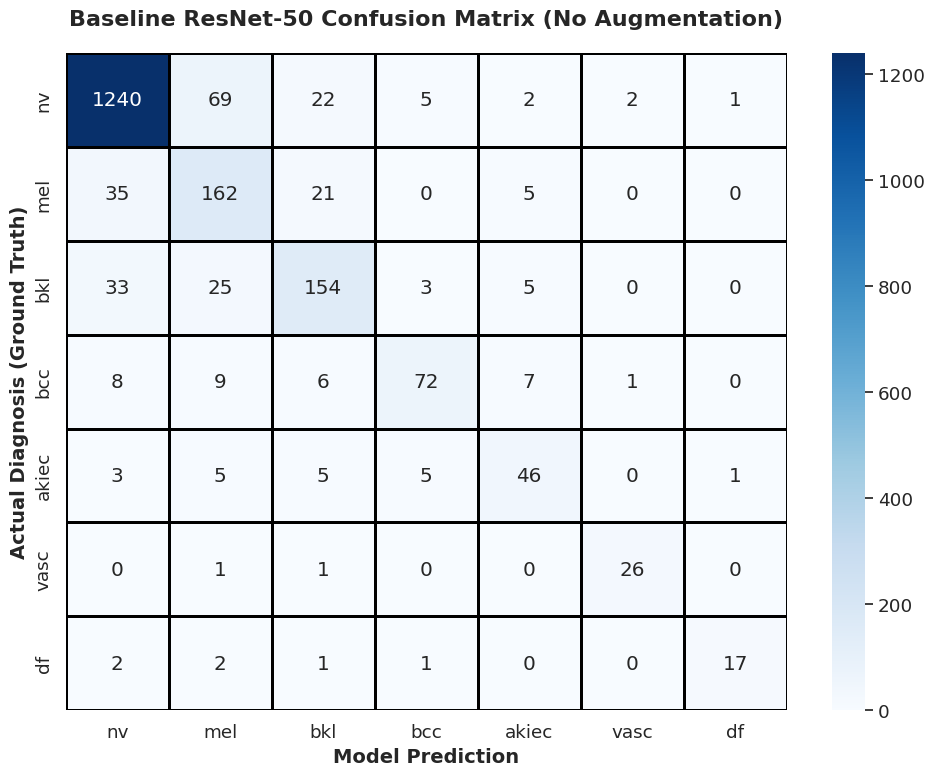

✅ Saved as 'baseline_confusion_matrix.png' in your Kaggle working directory.


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Generate the raw confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# 2. Define the class names in the exact order as your report
target_names = ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']

# 3. Set up the plot style
plt.figure(figsize=(10, 8))
sns.set(font_scale=1.2) # Make text larger for presentation slides

# 4. Plot using Seaborn
# cmap="Blues" is standard for professional academic papers
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names,
            linewidths=1, linecolor='black')

# 5. Add titles and labels
plt.title('Baseline ResNet-50 Confusion Matrix (No Augmentation)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Actual Diagnosis (Ground Truth)', fontsize=14, fontweight='bold')
plt.xlabel('Model Prediction', fontsize=14, fontweight='bold')

# 6. Save the image so you can download it from Kaggle!
plt.tight_layout()
plt.savefig('baseline_confusion_matrix.png', dpi=300)
plt.show()

print("✅ Saved as 'baseline_confusion_matrix.png' in your Kaggle working directory.")